---
# <div style="text-align: center"> Azos Tutorial 2: Lights On! Reaching the Photostationary State </div> 
---

Throughout the previous tutorials, <span style="color:blue">**SCOPE**</span> has interacted with different parts of the code to handle the execution of computational workflows. 

Here are the topics covered in this Azo add-on tutorial 2:
1) Navigating an existing SYSTEM.
2) Analysing TDDFT data
3) The LAMP class.
4) The Photostationary State (PSS)

## Part 1. Navigate an existing SYSTEM

In [1]:
import os
import scope 
import matplotlib.pyplot as plt
from    scope_azo.azo_classes               import *
from    scope_azo.azo_functions             import * 
from    scope.parse_general                 import search_string, read_lines_file 
from    scope.software.gaussian.g16_parse   import * 
from    scope.software.gaussian.g16_output  import * 

In [2]:
tutorial_folder = os.getcwd()+'/../Data/Azo/Tutorial_2/'
tutorial_folder = '/Users/sergivela/Documents/SCOPE/Tutorials_Run/Tutorial_azo/'

In [3]:
sys = scope.read_write.load_binary(tutorial_folder+'Systems/Tuto/Tuto.npy')

In [4]:
sys

-------------------------------------
   >>> SCOPE System_azo Object >>>   
-------------------------------------
 Name                  = Tuto
 Dihedral Indices:     = [1, 0, 15, 16, 17, 18]
 Version               = 1.0
 Type                  = system
 Subtype               = system_azo
 Source Path           = /home/svela/SCOPE/Tutorial_azo/Sources/Tuto/
 System File Path      = /home/svela/SCOPE/Tutorial_azo/Systems/Tuto/
 System File Name      = /home/svela/SCOPE/Tutorial_azo/Systems/Tuto/Tuto.npy
 Computations Path     = /home/svela/SCOPE/Tutorial_azo/Computations/Tuto/

 Num Sources           = 10
     idx: type, name, formula               
     0: specie, trans, H21-C17-N4-O-Cl 
     1: specie, cis, H21-C17-N4-O-Cl 
     2: specie, tsrot_a_s, H21-C17-N4-O-Cl 
     3: specie, tsrot_a_t, H21-C17-N4-O-Cl 
     4: specie, tsrot_b_s, H21-C17-N4-O-Cl 
     5: specie, tsrot_b_t, H21-C17-N4-O-Cl 
     6: specie, tsinv_l_a, H21-C17-N4-O-Cl 
     7: specie, tsinv_l_b, H21-C17-N4-O-Cl 
  

In [5]:
mets = sys.get_mets(temp=298.15, target_state='opt', debug=2)

SYSTEM_AZO.GET_METS: The target state in source trans is not a TS. Skipping
SYSTEM_AZO.GET_METS: The target state in source cis is not a TS. Skipping
SYSTEM_AZO.GET_METS: Found Singlet TS: tsrot_a_s, spin: 0
SYSTEM_AZO.GET_METS: Found Triplet Minimum: tsrot_a_t, spin: 2
SYSTEM_AZO.GET_METS: [WARNING] Gtot not found for State=opt of source=tsrot_a_t. Computing
STATE_AZO.CORRECT_TRIPLETG: Adding penalty of 5.05 kcal/mol.
STATE_AZO.CORRECT_TRIPLETG: Corrected Gtot. Data stored in state: -1413.32068811
STATE_AZO.CORRECT_TRIPLETG: Before correction: -1413.32872986 au. After correction: -1413.32068811
SYSTEM_AZO.GET_METS: Found Singlet TS: tsrot_b_s, spin: 0
SYSTEM_AZO.GET_METS: Found Triplet Minimum: tsrot_b_t, spin: 2
SYSTEM_AZO.GET_METS: [WARNING] Gtot not found for State=opt of source=tsrot_b_t. Computing
STATE_AZO.CORRECT_TRIPLETG: Adding penalty of 5.05 kcal/mol.
STATE_AZO.CORRECT_TRIPLETG: Corrected Gtot. Data stored in state: -1413.32033086
STATE_AZO.CORRECT_TRIPLETG: Before correcti

In [6]:
trans_sou = sys.find_source("trans")[1]
trans_state = trans_sou.find_state("opt")[1]
cis_sou = sys.find_source("cis")[1]
cis_state = cis_sou.find_state("opt")[1]

In [7]:
newpss = sys.get_PSS(lamp_name='coolled', target_state='opt', temp=298.15, lmin=250,lmax=600, debug=1)

STATE_AZO.GET_ABS_SPECTRUM: energies [2.798, 3.3985, 4.3701, 4.762, 4.8374, 5.361, 5.6077, 5.8545, 6.0196, 6.0858]
STATE_AZO.GET_ABS_SPECTRUM: osc. strengths [0.0, 0.378, 0.4587, 0.0004, 0.0095, 0.1318, 0.0114, 0.3351, 0.1044, 0.0017]
STATE_AZO.GET_ABS_SPECTRUM: erange 2.0664-4.9594
BUILD_SPECTRUM: Using sigma=0.2
BUILD_SPECTRUM: x0: 2.798 y0: 0.0
BUILD_SPECTRUM: x0: 3.3985 y0: 0.378
BUILD_SPECTRUM: x0: 4.3701 y0: 0.4587
BUILD_SPECTRUM: x0: 4.762 y0: 0.0004
BUILD_SPECTRUM: x0: 4.8374 y0: 0.0095
BUILD_SPECTRUM: x0: 5.361 y0: 0.1318
BUILD_SPECTRUM: x0: 5.6077 y0: 0.0114
BUILD_SPECTRUM: x0: 5.8545 y0: 0.3351
BUILD_SPECTRUM: x0: 6.0196 y0: 0.1044
BUILD_SPECTRUM: x0: 6.0858 y0: 0.0017
STATE_AZO.GET_ABS_SPECTRUM: energies [2.5813, 3.7324, 4.6209, 4.7859, 4.8935, 4.9582, 5.2438, 5.4487, 5.6114, 5.7835]
STATE_AZO.GET_ABS_SPECTRUM: osc. strengths [0.0348, 0.0955, 0.0905, 0.0264, 0.0064, 0.0021, 0.0795, 0.0871, 0.0886, 0.1769]
STATE_AZO.GET_ABS_SPECTRUM: erange 2.0664-4.9594
BUILD_SPECTRUM: Usin

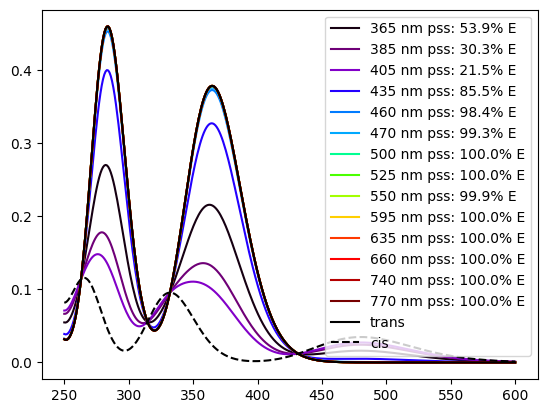

In [8]:
newpss.plot_spectra()

In [9]:
trans_state.shift_exc_states_wl(50)
cis_state.shift_exc_states_wl(50)

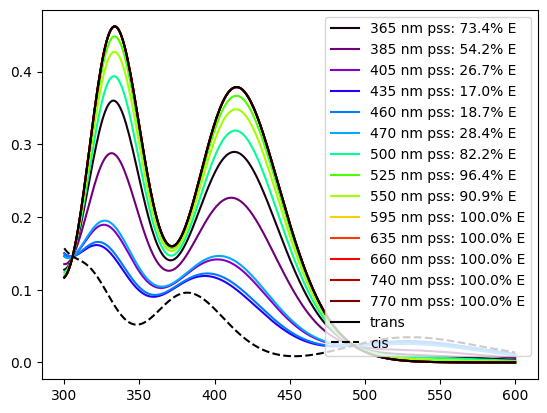

In [10]:
shifted_pss = sys.get_PSS(lamp_name='coolled', target_state='opt', temp=298.15, lmin=300, lmax=600, debug=0)
shifted_pss.plot_spectra()

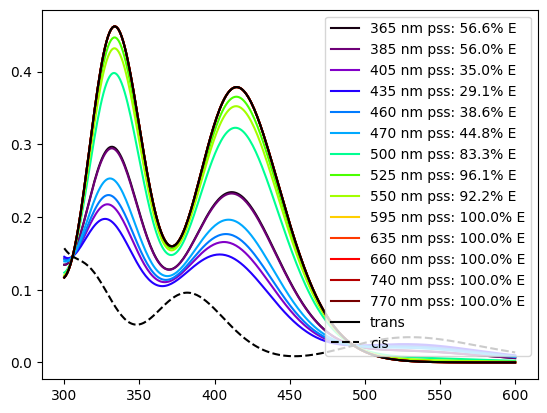

In [11]:
shifted_pss = sys.get_PSS(lamp_name='test', target_state='opt', temp=298.15, lmin=300, lmax=600, debug=0)
shifted_pss.plot_spectra()

In [1]:
sys.get_cis_halflife_time(temp=298.15, debug=0)

NameError: name 'sys' is not defined

In [ ]:
sys.get_cis_halflife_time(temp=500, debug=0)

cis_halflife_time:   0.00012220 s (at temperature=500)

In [ ]:
sys.get_thermal_stability('opt', temp=10, debug=1)

SYSTEM_AZO.get_thermal_stability: gtot_trans=-1413.3524544962547
SYSTEM_AZO.get_thermal_stability: gtot_cis=-1413.331444157392


dG_cis-trans:  13.18418950 kcal/mol

In [ ]:
sys.get_thermal_stability('opt', temp=300, debug=1)

SYSTEM_AZO.get_thermal_stability: gtot_trans=-1413.372930558069
SYSTEM_AZO.get_thermal_stability: gtot_cis=-1413.3511796622831


dG_cis-trans:  13.64889609 kcal/mol

In [ ]:
found, trans = sys.find_source('trans')
found_state, trans_state = trans.find_state('opt')

found, cis = sys.find_source('cis')
found_state, cis_state = cis.find_state('opt')

In [ ]:
Gtot_trans = trans_state.results["Gtot"] 

for d in trans_state.results["Gtot"].datas:
    print(d.temperature)

10
300


In [ ]:
Gtot_cis = cis_state.results["Gtot"] 

for d in cis_state.results["Gtot"].datas:
    print(d.temperature)

298.15
500
10
300


In [ ]:
trans_state

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = opt
 Source Name           = trans
 Source Type           = specie
 Labels                = C...
 Coord                 = [-0.263217, 0.194815, -0.255084]...
 Number of Units (Z)   = 1

 Has VNMs              = YES
 Is Minimum            = True
 Is a Transition State = False
 First Freq (cm-1)     = 15.299

 Has Excited States    = YES
 # Molecules:          = 1
 With Formulae:                               
    0: H21-C17-N4-O-Cl 

In [ ]:
trans_state.results["Gtot"].datas

[Gtot: -1413.35245450 au (at temperature=10),
 Gtot: -1413.37293056 au (at temperature=300)]

In [ ]:
trans_state.get_thermal_data(temp=10, overwrite=True)

In [ ]:
trans_state.results["Gtot"].find_value_with_property('temperature', 10)

Gtot: -1413.35245450 au (at temperature=10)

In [ ]:
type(trans_state)

scope_azo.azo_classes.State_azo

In [ ]:
sys.get_cis_halflife_time(debug=1)

SYSTEM_AZO.GET_METS: The target state in source trans is not a TS. Skipping
SYSTEM_AZO.GET_METS: The target state in source cis is not a TS. Skipping
SYSTEM_AZO.GET_METS: Found Singlet TS: tsrot_a_s, spin: 0
SYSTEM_AZO.GET_METS: Found Triplet Minimum: tsrot_a_t, spin: 2
STATE_AZO.CORRECT_TRIPLETG: Adding penalty of 5.05 kcal/mol.
STATE_AZO.CORRECT_TRIPLETG: Corrected Gtot. Data stored in state: -1413.32068811
STATE_AZO.CORRECT_TRIPLETG: Before correction: -1413.32872986 au. After correction: -1413.32068811
SYSTEM_AZO.GET_METS: Found Singlet TS: tsrot_b_s, spin: 0
SYSTEM_AZO.GET_METS: Found Triplet Minimum: tsrot_b_t, spin: 2
STATE_AZO.CORRECT_TRIPLETG: Adding penalty of 5.05 kcal/mol.
STATE_AZO.CORRECT_TRIPLETG: Corrected Gtot. Data stored in state: -1413.32033086
STATE_AZO.CORRECT_TRIPLETG: Before correction: -1413.32837260 au. After correction: -1413.32033086
SYSTEM_AZO.GET_METS: Found Singlet TS: tsinv_l_a, spin: 0
SYSTEM_AZO.GET_METS: Found Singlet TS: tsinv_l_b, spin: 0
SYSTEM_AZO

cis_halflife_time:   9.15292786 s

In [ ]:
print(sys.sources[1].states[1].results)
print(sys.sources[2].states[1].results)

{'energy': energy: -1413.69646642 au, 'Helec': Helec: -1413.69646642 au, 'Selec': Selec:   0.00000000 au, 'Hvib': ---------------------------------------------------
   COLLECTION OF DATA   = Hvib                
---------------------------------------------------
 Variable              = temperature
 Num of Entries        = 4
 First                 = 0.38438635341342386
 Last                  = 0.3846210800650477
 Units                 = au
 Function              = scope.thermal_corrections.get_Hvib()
, 'Svib': ---------------------------------------------------
   COLLECTION OF DATA   = Svib                
---------------------------------------------------
 Variable              = temperature
 Num of Entries        = 4
 First                 = 0.00013032956573857937
 Last                  = 0.00013111440782731333
 Units                 = au
 Function              = scope.thermal_corrections.get_Svib()
, 'Gtot': ---------------------------------------------------
   COLLECTION OF DA

In [ ]:
# We have created an example of a system with a name and a smiles. 
name = 'Azo'
smiles = 'C1(=C(N)C(Cl)=CC(C(O)CNC(C)C)=C1)/N=N/c1ccccc1'

# Note that it has 8 sources: 
#   - 2 isomers (Z/E)
#   - 6 Transition States (Rotation in the singlet and the triplet states, inversion TS)

azo_sys

NameError: name 'azo_sys' is not defined

In [ ]:
# PARSEIG DE LES OPTIMITZACIONS, FREQS I TDDFT

for source in azo_sys.sources:
    # Sets Filenames and folders
    if   source.name.lower() == "cis":   prefix = "Z"
    elif source.name.lower() == "trans": prefix = "E"
    elif source.name.lower() == "tsrot_a_s": prefix =  "TSrot_A_S"
    elif source.name.lower() == "tsrot_a_t": prefix =  "TSrot_A_T"
    elif source.name.lower() == "tsrot_b_s": prefix =  "TSrot_B_S"
    elif source.name.lower() == "tsrot_b_t": prefix =  "TSrot_B_T"
    elif source.name.lower() == "tsinv_l": prefix =    "TSinv_L"
    elif source.name.lower() == "tsinv_r": prefix =    "TSinv_R"

    else:
        raise Exception
 
    opt_file = str(f"{azo_sys.name}_{prefix}.log")
    tda_file = str(f"{azo_sys.name}_{prefix}_TD.log")


    opt_isfinished = False
    tda_isfinished = False
    if opt_file in sorted(os.listdir(tutorial_folder)):
        opt_filepath = tutorial_folder+opt_file
        # print('Found: ', filepath)
        opt_isfinished = True

    if tda_file in sorted(os.listdir(tutorial_folder+'TDDFT/')):
        
        tda_filepath = tutorial_folder + 'TDDFT/' + tda_file
        print(f'Found {tda_filepath}')
        tda_isfinished =True

    if opt_isfinished:
        print("Parsing", opt_filepath)
        opt_state = source.add_state("opt")  
        source.link_opt_to_state(opt_state, opt_filepath)
        if tda_isfinished:
            source.link_tda_to_state(opt_state, tda_filepath)
        else:
            print(f'TDDFT data was not found for {source.name}')



In [ ]:
cis = azo_sys.find_source('cis')[1]
cis_state = cis.find_state('opt')[1]
trans = azo_sys.find_source('trans')[1]
triplet = azo_sys.find_source('tsrot_a_t')[1]
triplet_state = triplet.find_state("opt")[1]
tsrot_a = azo_sys.find_source('tsrot_a_s')[1]
tsrot_a_state = tsrot_a.find_state('opt')[1]

In [ ]:
cis_state.results

In [ ]:
triplet_state.results

In [ ]:
# It is possible to compute half-lives for isomers cis and trans using the Eyring equation (1). 
# As it needs the difference in free energy from the isomer to the Transition State, it is 
#   important to carry out an 'opt' and 'freq' jobs in SCOPE. 

# Considering a first order reaction, it is possible to get the half-life time (2). 

$$
(1) \quad k = \kappa \frac{k_B T}{h} e^{-\frac{\Delta G^\ddagger}{RT}}
$$ 
$$
(2) \quad t_{1/2}= \frac{ln(2)}{k}
$$

In [ ]:
# There is a function that computes both t1/2 and k: compute_t. It computes the half-life time in s 
#   - g_ts : free energy of the Transition State, in hartrees.
#   - g_iso : free energy of the isomer, in hartrees. 
#   - T : temperature, in Kelvin

g_iso = cis_state.results['Gtot'].value
g_ts = tsrot_a_state.results['Gtot'].value

t, k = compute_t(g_ts, g_iso, T=300)

# It will return both the half-time [s] and the rate constant [s^-1]. The time can be converted to 
# a comprehensive unit with the function format_time(t)

print(str(t)+' s')
print(str(k)+' s^-1')
format_time(t)

In [ ]:
# To make it more comfortable, the function set_halflife_time() used with a Molecule_azo source does everything. 

cis.set_halflife_time(skip_triplets=False, overwrite=True)
trans.set_halflife_time(skip_triplets=False, overwrite=True)

In [ ]:
trans.set_halflife_time?


In [ ]:
# For the TSrot in the triplet state, they present lower energies than they should, since their TS geometries 
# correspond to a minima in the triplet PES. 
# As the isomer is, in principle, in the singlet state. It involves a non-zero probability of intersystem crossing (ISC), 
# which assumes an energy penalty that increases the energetic cost. 
# To do so, literature recommends to use an approximation of a non-adiabatic rate as:

$$
k_{NA} = \kappa · k_{adiabatic}
$$

In [ ]:
# For an adiabatic process the kappa equals 1, so it corresponds to the Eyring theory. 
# In literature, a suitable value for the surface-hopping probability, p_sh, is 0.0002. 
# This penalty is around 5 kcal/mol, which must be added to the free energy of the TSrot in the triplet state.

# This is automatically carried out when calling set_halflife_time(). 

In [ ]:
# Now, the results have been stored as Data from their States.
cis.find_state('opt')[1].results
trans.find_state('opt')[1].results

In [ ]:
# And it is possible to store which is the minimum energy transition state (METS) by: 
cis.mets

In [ ]:
# This can be checked by the plot_energies() method included in System_azo objects.
# The plot_energies method shows the free energy levels with respect to their minimum energy isomer. 

# It should highlight the minimum energy Transition State. 
import matplotlib.pyplot as plt
azo_sys.plot_energies()

# This function also displays the values of each energy barrier from the Trans isomer to their TS, in kcal/mol. 

In [ ]:
show_thermal_data([azo_sys])

## Part 2. Analysing TDDFT data

In [ ]:
cis_state = azo_sys.find_source('cis')[1].find_state('opt')[1]
trans_state = azo_sys.find_source('trans')[1].find_state('opt')[1]


In [ ]:
cis_state.es_list

In [ ]:

lambda_grid, sigma_Z, sigma_E = get_abs_spectrum(cis_state,trans_state)
plt.plot(lambda_grid, sigma_Z, '--')
plt.plot(lambda_grid, sigma_E, '--')
plt.xlim(220, 600)


WIP WIP WIP WIP \
The **photostationary state (PSS)** is the fraction of each isomer if a mixture of cis/trans isomers is irradiated by light during a certain period of time and it .

To do so, the steady-state population is modelled by the proper contribution of the thermal and optical (photonic) rates:


$$
\chi _E = \frac{k_{th}^{ZE} + k_{ph}^{ZE}} {k_{ph}^{EZ} + k_{ph}^{ZE} + k_{th}^{EZ} + k_{th}^{ZE}}
$$

where:

- $
k_{th}^{ZE} = \dfrac{ln(2)}{t^{ZE}}
$
-   $
k_{ph}^{ZE} = \Phi_{ZE} \quad* \quad \int (\sigma_Z (\lambda) · \phi · \lambda) d\lambda
$ 

where: 

WIP WIP WIP WIP

## Part 3. Lights On: The LAMP Class 

As the sample needs to be irradiated by a light source, it needs a proprer modelling. For that, the existence of a Lamp class object has been created is needed. It stores relevant data for later use in optical relaxation. 

From now on, 

In [ ]:
from scope_azo.azo_classes import Lamp

In [ ]:
# To create a Lamp it needs a name and wavelength. The name must be a string and the wavelength is an integer. 
# It is also possible to provide some additional data:

#       - fwhm_nm: Full Width at Half Maximum of the source, as it depends on the Light Source equipment 
#                  and its incorporated light filters. If it is set as None, it will apply a minimum FWHM of 1 nm. 

#       - power: The power of the light source, in W

#       - shift_nm: As many computational experiments are not usually reliable from the experiments in the lab, 
#                   it is possible to provide a shift, to easily compare computational spectra and experiment measurements. 
#                   The selected value will apply an effective wavelength, it is stored in 
#                  
# Accessible variables:
# _____________________

#       - self.eff_wavelength: real - shift (which means moving the lamp to the blue in the visible spectrum) 
#       - self.irradiance, in W/m^2


In [ ]:
# It may seem quite difficult, but we have a solution for that.

# By default, some data extracted from a COOLLED light source equipment is stored. 
# It is selected automatically once you insert a wavelength value, in nm. 
# If a certain wavelength is not included in the Lamp class by default, it will raise an error:

Lamp('Blue', wavelength=501,shift_nm=50)

# And the error shows the available wavelengths. Just select one of them. 

In [ ]:
# It is also possible to do an experiment without light source or a Dark experiment
# If you set the name of the Lamp as 'DARK', its power and irradiance will be set to zero.

Lamp('DARK', wavelength=365) 

# Do not worry about the wavelength, a source at any wavelength can not emmit light if the power
# of the lamp is zero. Obvious, isn't it?  

In [ ]:
# For now, let's create a lamp called Green, stored in the variable green_lamp and with a shift of 50 nm to the blue region. 
green_lamp = Lamp('Green', wavelength=500, shift_nm=50)

## Part 4. Ready, steady... Reaching the Photostationary State (PSS). 

In [ ]:
# To carry out an experiment, the sample is irradiated by using 
wl_list = [365, 385, 405, 435, 460, 470, 500, 525, 550]

azo_sys.compute_pss(wl_list=wl_list,shift_nm=70)

In [ ]:
azo_sys.pss_data.keys()

In [ ]:
azo_sys.plot_pss(solvent='Gas')